# Phase II: Surroundings

**Building:** Linear Building · **Model:** `models/linear_surroundings.idf` · **Weather:** `weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw` · **Output:** `results/linear_surroundings_orientation_results.csv`

Multi-objective optimization (NSGA-II via BESOS) minimizing cooling and heating demand with a single decision variable (building orientation, EnergyPlus `North Axis`, 0–359°). Run this notebook from its own folder (paths are relative to `notebooks/`).

## Running the evaluations for the optimization


### *Import* of libraries

In [1]:
from besos import eppy_funcs as ef
from besos import eplus_funcs as ep
from besos.problem import EPProblem
from besos.objectives import *
from besos.evaluator import EvaluatorEP
from besos.parameters import wwr, RangeParameter, FieldSelector, FilterSelector, GenericSelector, Parameter, expand_plist
from besos.optimizer import NSGAII, SPEA2
from platypus.evaluator import MapEvaluator
import platypus
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dask.distributed import Client

### Simulation model

In [2]:
building = ef.get_building('../models/linear_surroundings.idf') # Loading the E+ model;

### Variables of the multi-objective analysis

In [3]:
parameters = []

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="BUILDING",             # Class of E+;
                    object_name="RosaBrasil",    # Object name;
                    field_name="North Axis", # Object field;
                ),
                name='Orientation',
                value_descriptor=RangeParameter(min_val=0, max_val=359)      # Range
                )
            )

### Selection of the analysis objectives

In [4]:
demanda_resf = MeterReader('DistrictCooling:HVAC', name="Cooling demand (kWh/m²)")
demanda_aquec = MeterReader('DistrictHeating:HVAC', name="Heating demand (kWh/m²)")
EPobjectives = [demanda_resf,demanda_aquec] # cooling and heating as objectives;
problem = EPProblem(parameters, EPobjectives)  # Creating an instance of the problem;

### NSGA-II evaluation function and parameters definition + runtime

In [5]:
evaluator = EvaluatorEP(problem, building, epw="../../../weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw")   # Evaluation function with the problem and the model;
startTime = datetime.now()
results = NSGAII(evaluator, evaluations=200, population_size=100)   # running the NSGA-II;
print(datetime.now() - startTime)

9:08:57.510260


### Results

In [6]:
results

,Orientation,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,333.509261,1.672646e+11,1.012553e+11,0,True
1,182.314136,1.513233e+11,1.116940e+11,0,True
2,178.861055,1.589270e+11,1.021766e+11,0,True
3,22.385583,1.587747e+11,1.111250e+11,0,True
4,200.287447,1.574840e+11,1.114349e+11,0,True
...,...,...,...,...,...
95,261.428075,1.570454e+11,1.180582e+11,0,False
96,261.198965,1.570730e+11,1.180460e+11,0,False
97,277.958258,1.565836e+11,1.181644e+11,0,False
98,325.752606,1.679726e+11,1.015660e+11,0,False


### *Plot* of the results (heating and cooling demand in kWh/m²·year)

In [7]:
import math
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']*pow(10,-9))
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']*pow(10,-9))
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/0.0036)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/0.0036)
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/884.00)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/884.00)

results

,Orientation,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,333.509261,52.559279,31.817261,0,True
1,182.314136,47.550044,35.097419,0,True
2,178.861055,49.939364,32.106783,0,True
3,22.385583,49.891498,34.918619,0,True
4,200.287447,49.485921,35.015998,0,True
...,...,...,...,...,...
95,261.428075,49.348109,37.097220,0,False
96,261.198965,49.356778,37.093389,0,False
97,277.958258,49.203000,37.130599,0,False
98,325.752606,52.781730,31.914918,0,False


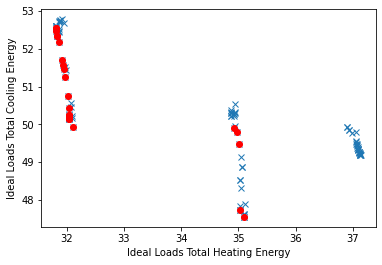

In [8]:
optres = results.loc[results['pareto-optimal']==True,:] # pareto-optimal
plt.plot(results['Heating demand (kWh/m²)'], results['Cooling demand (kWh/m²)'],'x') # Plot all results in 'x'
plt.plot(optres['Heating demand (kWh/m²)'], optres['Cooling demand (kWh/m²)'],'ro') # Plot of the best solutions in red
plt.xlabel('Ideal Loads Total Heating Energy')
plt.ylabel('Ideal Loads Total Cooling Energy')
plt.savefig("../results/linear_surroundings_orientation_pareto.png")
#plt.axis([0.00,0.08,0.0,1.6]) #Set the dimension of the chart

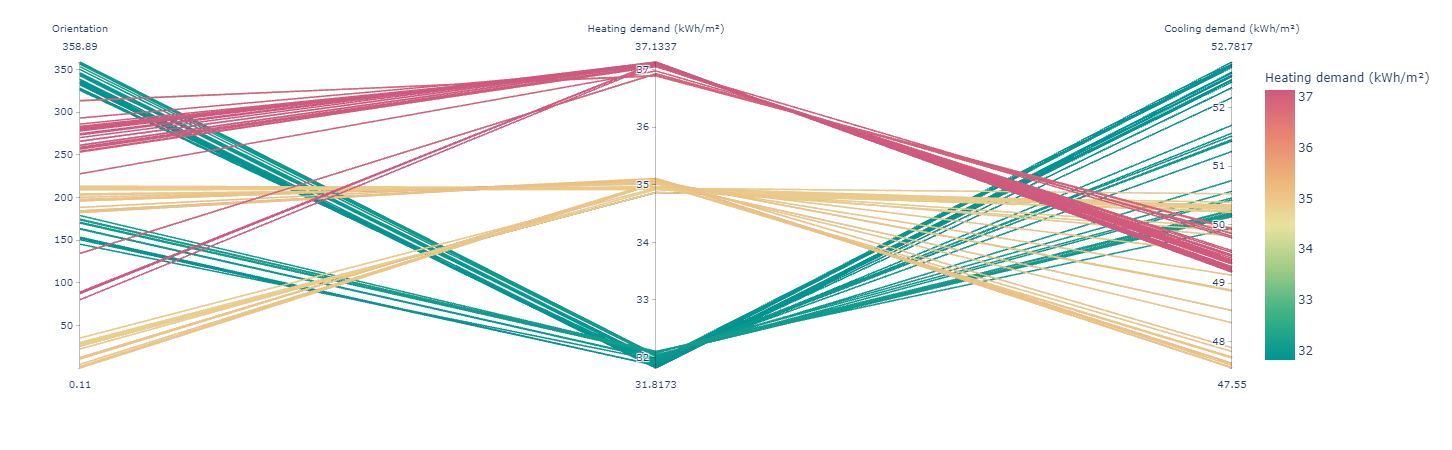

In [9]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.express as px
fig = px.parallel_coordinates(results,color="Heating demand (kWh/m²)", dimensions=["Orientation","Heating demand (kWh/m²)","Cooling demand (kWh/m²)"],
    color_continuous_scale=px.colors.diverging.Temps)
fig.show()

In [10]:
optres

,Orientation,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,333.509261,52.559279,31.817261,0,True
1,182.314136,47.550044,35.097419,0,True
2,178.861055,49.939364,32.106783,0,True
3,22.385583,49.891498,34.918619,0,True
4,200.287447,49.485921,35.015998,0,True
5,0.111964,47.719952,35.022825,0,True
6,350.075465,50.755869,32.015960,0,True
7,346.094137,51.253543,31.967066,0,True
8,338.729418,52.172686,31.863782,0,True
9,342.827898,51.701598,31.923849,0,True


In [11]:
results.to_csv('../results/linear_surroundings_orientation_results.csv')

In [12]:
min_idealloads = results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']
min_idealloads = min_idealloads[min_idealloads == min_idealloads.min()]
bestone = results[(results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']) == min_idealloads.min()]
bestone

,Orientation,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
2,178.861055,49.939364,32.106783,0,True
